# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

Face recognition is a method of identifying or verifying the identity of an individual using their face. Face recognition systems can be used to identify people in photos, video, or in real-time. The recent major breakthrough in increasing the face recognition accuracy has come from advancements in Deep Learning and CNNs.

**Objectives:**

**Stage 1:** Build a Siamese Network and obtain the Siamese Representation for the AT&T faces dataset

**Stage 2 (10 Marks):** Use the same Siamese Model to deploy the application for Face Similarity on HuggingFace spaces

**Stage 3 (10 Marks):** Get the Siamese Network Representation of the Team Data and build a classifier to perform Face Recognition


##**Stage 1: Build a Siamese Network**


---


* Define a Siamese network and obtain Siamese Representation on the AT&T Faces Dataset (code given)


**Dataset download**

The [AT&T Faces Dataset](https://git-disl.github.io/GTDLBench/figures/faces.gif) contains 10 different images of each of 40 distinct persons. Images were taken with variations in times, lighting, facial expressions and facial details (eg. glasses / no glasses).

Dataset Statistics: Color: Grayscale; Sample Size: 92x112; Total Samples: 400; Dataset Size: 4.5 MB (compressed in .tar.z)

In [1]:
#@title #####Download the AT&T Dataset.

from IPython import get_ipython
ipython = get_ipython()

notebook="M3_Hackathon" #name of the notebook

def setup():
    ipython.magic("sx wget https://cdn.talentsprint.com/aiml/FaceRecogHackathon/Datasets/ATandT/data-20190607T005435Z-001.zip")
    ipython.magic("sx unzip -qq data-20190607T005435Z-001.zip")
    ipython.magic("sx wget https://cdn.iisc.talentsprint.com/AIandMLOps/Datasets/lbpcascade_frontalface.xml")

    print ("Setup completed successfully")
    return
setup()

Setup completed successfully


In [2]:
%ls

data/  data-20190607T005435Z-001.zip  lbpcascade_frontalface.xml  sample_data/


#### **Import Required Packages**


In [3]:
%matplotlib inline
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
import torchvision.utils
import numpy as np
import random
import cv2
from PIL import Image       # PIL (Pillow) is the Python Image Library. Used to cut and resize images, or do simple manipulation.
import torch
from torch.autograd import Variable
import PIL.ImageOps
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

**Helper functions**

In [4]:
## The below function plots a given tensor image
def imshow(img,text=None,should_save=False):
    npimg = img.numpy()
    plt.axis("off")
    if text:
        plt.text(75, 8, text, style='italic',fontweight='bold', bbox={'facecolor':'white', 'alpha':0.8, 'pad':10})
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    # In PyTorch, the order of dimension is "channel*width*height" but in matplotlib it is "width*height*channel".
    # So a transpose is performed to correctly index the dimensions
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

## We will use the below method to plot the loss graph while training
def show_plot(iteration,loss):
    plt.plot(iteration,loss)
    plt.show()

**Configuration class**

In [5]:
# A simple class to manage all configurations
class Config():
    training_dir = "./data/faces/training/"
    testing_dir = "./data/faces/testing/"
    train_batch_size = 64
    train_number_epochs = 100

**Display a sample image**

(112, 92, 3)


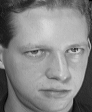

In [6]:
import cv2
from google.colab.patches import cv2_imshow

# Opencv's imread takes full path of an image as input to read an image
im1 = cv2.imread('./data/faces/training/s1/10.pgm')
print(im1.shape)
cv2_imshow(im1)

(112, 92, 3)


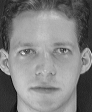

In [7]:
# Opencv's imread takes full path of an image as input to read an image
im1 = cv2.imread('./data/faces/training/s1/1.pgm')
print(im1.shape)
cv2_imshow(im1)

(112, 92, 3)


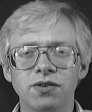

(112, 92, 3)


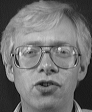

In [11]:
# Opencv's imread takes full path of an image as input to read an image
im1 = cv2.imread('./data/faces/training/s2/10.pgm')
print(im1.shape)
cv2_imshow(im1)

im1 = cv2.imread('./data/faces/training/s2/8.pgm')
print(im1.shape)
cv2_imshow(im1)

#### **Define a custom SiameseNetworkDataset class**

This dataset generates a pair of images. 0 for geniune pair (similar) and 1 for imposter pair (dissimilar)

In [20]:
# Below is the class of custom dataset which arranges images in pairs and gives the labels. if both are same, then label will be 0 otherwise 1
# As our images are in .pgm extension (portable gray map) we converting them 'L' to store luminance which is basically single channel image.

class SiameseNetworkDataset(Dataset):
    def __init__(self,imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset
        self.transform = transform

    # Overriding the data retriever (__getitem__) to provide a pair of images + similar/dissimilar label
    def __getitem__(self,index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)
        #we need to make sure approx 50% of images are in the same class
        should_get_same_class = random.randint(0,1)
        if should_get_same_class:
            while True:
                #keep looping till the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs)
                print(f"{img1_tuple}\n")
                print(f"Same {img0_tuple[1]}=={img1_tuple[1]}\n")
                if img0_tuple[1]==img1_tuple[1]:
                    print("Found Same\n")
                    break
        else:
            while True:
                #keep looping till a different class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs)
                print(f"Diff {img0_tuple[1]}=={img1_tuple[1]}\n")
                if img0_tuple[1] !=img1_tuple[1]:
                    print("Found Diff\n")
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])
        img0 = img0.convert("L")
        img1 = img1.convert("L")

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)

        return img0, img1 , torch.from_numpy(np.array([int(img1_tuple[1]!=img0_tuple[1])],dtype=np.float32))

    def __len__(self):
        return len(self.imageFolderDataset.imgs)

**Create an Image Folder Dataset**

In [21]:
folder_dataset = dset.ImageFolder(root=Config.training_dir)

**Create the Siamese Network Dataset**

In [22]:
# Create the object for the SiameseNetworkDataset class (defined earlier in this notebook);

# NOTE: the 'TRANSFORMS' HERE CONSISTS OF
# a) resizing to 100*100
# b) Converting to tensor.

# YOU HAVE TO APPLY THE SAME TRANSORMS WHEN DEPLOYING THE MODEL ON THE SERVER!!

siamese_dataset = SiameseNetworkDataset(imageFolderDataset = folder_dataset, transform = transforms.Compose([transforms.Resize((100,100)), transforms.ToTensor()]))

In [37]:
len(siamese_dataset)

30

In [38]:
next(iter(siamese_dataset))

Diff 2==1

Found Diff



(tensor([[[0.1922, 0.2039, 0.1961,  ..., 0.2392, 0.2392, 0.2353],
          [0.2078, 0.2000, 0.2078,  ..., 0.2431, 0.2314, 0.2471],
          [0.2039, 0.2039, 0.2157,  ..., 0.2314, 0.2314, 0.2471],
          ...,
          [0.1922, 0.1961, 0.1922,  ..., 0.2510, 0.2510, 0.2588],
          [0.2000, 0.2000, 0.1882,  ..., 0.2549, 0.2471, 0.2588],
          [0.1961, 0.1961, 0.1961,  ..., 0.2510, 0.2392, 0.2471]]]),
 tensor([[[0.6118, 0.6039, 0.6039,  ..., 0.5922, 0.5843, 0.5882],
          [0.6000, 0.6078, 0.6039,  ..., 0.5882, 0.5922, 0.5882],
          [0.6000, 0.6000, 0.6078,  ..., 0.5922, 0.5882, 0.5922],
          ...,
          [0.5451, 0.5412, 0.5255,  ..., 0.4392, 0.4275, 0.4314],
          [0.5412, 0.5255, 0.5686,  ..., 0.4275, 0.4314, 0.4196],
          [0.5725, 0.7059, 0.7961,  ..., 0.4157, 0.4314, 0.4157]]]),
 tensor([1.]))

**Exclude malformed images to avoid image loading errors** (Use Nonechucks)

In [ ]:
# In cases where your dataloader gives 'image not found' error i.e.
# if an image is malformed, nonechucks helps in eliminating those images so that your dataloader doesn't fail.
# So good practice to use this code below

#!pip install Nonechucks
#import nonechucks as nc

In [ ]:
## The below line will avoid loading the image files that are corrupted or unreadable.
#siamese_dataset = nc.SafeDataset(siamese_dataset)

**Visualising some of the data**
The top row and the bottom row of any column is one pair. The 0s and 1s correspond to the column of the image.
1 indiciates dissimilar, and 0 indicates similar.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


('./data/faces/training/s8/5.pgm', 35)
('./data/faces/training/s23/9.pgm', 15)
Diff 1==14
Diff 33==6
Diff 21==22

Diff 32==13

Diff 36==28
Found Diff



Same 1==35


Found Diff

Found Diff


('./data/faces/training/s40/8.pgm', 34)

('./data/faces/training/s20/3.pgm', 12)
Found Diff
Same 34==15
Found Diff
Same 1==34





('./data/faces/training/s21/7.pgm', 13)
('./data/faces/training/s37/9.pgm', 30)
('./data/faces/training/s26/10.pgm', 18)



('./data/faces/training/s16/7.pgm', 7)
Same 23==30

('./data/faces/training/s9/6.pgm', 36)
Same 34==13

Same 9==12
Same 1==7





Diff 26==28
('./data/faces/training/s33/6.pgm', 26)

Same 23==18
('./data/faces/training/s19/4.pgm', 10)
('./data/faces/training/s21/8.pgm', 13)

Diff 23==21




Found Diff

('./data/faces/training/s34/4.pgm', 27)
Same 9==26
Found Diff
Same 1==10


Same 34==13
Same 31==36


Same 23==27
('./data/faces/training/s37/8.pgm', 30)


('./data/faces/training/s16/3.pgm', 7)


Diff 20==8
('./data/faces/training/s17/3.pgm', 8)
('./

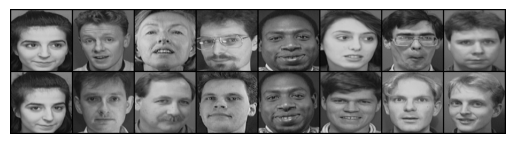


Same 4==26

Same 13==28
('./data/faces/training/s23/7.pgm', 15)

[[0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]]
Same 5==32

Same 15==18
('./data/faces/training/s10/4.pgm', 1)
Same 7==35





Same 31==5
Same 8==1

('./data/faces/training/s36/8.pgm', 29)
('./data/faces/training/s25/2.pgm', 17)
Same 33==15
('./data/faces/training/s27/8.pgm', 19)

('./data/faces/training/s9/8.pgm', 36)

('./data/faces/training/s3/10.pgm', 22)



('./data/faces/training/s13/8.pgm', 4)


In [23]:
vis_dataloader = DataLoader(siamese_dataset, shuffle=True, num_workers=8, batch_size=8)

dataiter = iter(vis_dataloader)

example_batch = next(dataiter)
concatenated = torch.cat((example_batch[0],example_batch[1]),0)
imshow(torchvision.utils.make_grid(concatenated))
print(example_batch[2].numpy())

#### **Neural Net Definition**

We will use a standard convolutional neural network

In [24]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.ReflectionPad2d(1),       #Pads the input tensor using the reflection of the input boundary, it similar to the padding.
            nn.Conv2d(1, 4, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(4),

            nn.ReflectionPad2d(1),
            nn.Conv2d(4, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),


            nn.ReflectionPad2d(1),
            nn.Conv2d(8, 8, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(8*100*100, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 500),
            nn.ReLU(inplace=True),

            nn.Linear(500, 5))

    # forward_once is for one image. This can be used while classifying the face images
    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

**Contrastive Loss**

In [25]:
class ContrastiveLoss(torch.nn.Module):
    """
    Contrastive loss function.
    Based on: http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    """

    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))

        return loss_contrastive

**Training the model**

In [26]:
train_dataloader = DataLoader(siamese_dataset, shuffle=True, num_workers=8, batch_size=Config.train_batch_size)

In [27]:
net = SiameseNetwork().cuda()
criterion = ContrastiveLoss()
optimizer = optim.Adam(net.parameters(),lr = 0.0005)

In [28]:
counter = []
loss_history = []
iteration_number= 0

In [29]:
%%capture
for epoch in range(0,Config.train_number_epochs):
    for i, data in enumerate(train_dataloader,0):
        img0, img1 , label = data
        img0, img1 , label = img0.cuda(), img1.cuda() , label.cuda()
        optimizer.zero_grad()
        output1,output2 = net(img0,img1)
        loss_contrastive = criterion(output1,output2,label)
        loss_contrastive.backward()
        optimizer.step()
        if i %10 == 0 :
            print("Epoch number {}\n Current loss {}\n".format(epoch,loss_contrastive.item()))
            iteration_number +=10
            counter.append(iteration_number)
            loss_history.append(loss_contrastive.item())

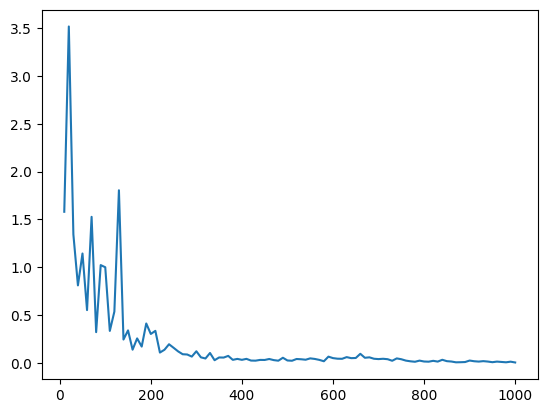

In [30]:
# Plotting the loss graph using the function show_plot
show_plot(counter,loss_history)

**Saving and loading model**

https://pytorch.org/tutorials/beginner/saving_loading_models.html

In [31]:
## Saving the model as a state dictionary
state = {'net_dict': net.state_dict()}
torch.save(state, './siamese_model.t7')

**Verifying the saved model with load_state_dict**

In [32]:
myModel = SiameseNetwork().cuda()

In [33]:
%ls

data/                          lbpcascade_frontalface.xml  siamese_model.t7
data-20190607T005435Z-001.zip  sample_data/


In [34]:
ckpt = torch.load('./siamese_model.t7')

In [35]:
# Save the state dictionary of the Siamese network (use pytorch only), It will be useful in integrating to the mobile app
# A state_dict is simply a Python dictionary object that maps each layer of the network to its parameters (weights)
# As a Python dictionary it can be easily saved, updated, altered and restored, adding a great deal of modularity to PyTorch models

myModel.load_state_dict(ckpt['net_dict'])

<All keys matched successfully>

##### Create the siamese dataset for the `testing_dir` and also the respective data loader. The Distance between each image pair denotes the degree of similarity the model found between the two images. Less means it found the images more similar, while higher values indicate it found them to be dissimilar.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Diff 2==2
Diff 1==2
('./data/faces/testing/s5/2.pgm', 0)


('./data/faces/testing/s7/2.pgm', 2)

('./data/faces/testing/s6/8.pgm', 1)
('./data/faces/testing/s7/2.pgm', 2)


Found Diff

Same 0==0
Diff 2==1
Same 0==2



Same 1==2
Same 2==1

Found Diff
Found Same

('./data/faces/testing/s5/10.pgm', 0)


('./data/faces/testing/s5/5.pgm', 0)


('./data/faces/testing/s7/9.pgm', 2)
Diff 1==0

Same 0==0

Same 1==0
Diff 0==1



Same 2==2
Found Same

Found Diff



('./data/faces/testing/s7/10.pgm', 2)
Diff 1==0
Found Same

Found Diff



Found Diff
Same 1==2


Diff 0==1
('./data/faces/testing/s7/1.pgm', 2)


Found Diff
('./data/faces/testing/s7/5.pgm', 2)
Same 1==2


('./data/faces/testing/s7/5.pgm', 2)

Same 1==2


Same 1==2
('./data/faces/testing/s6/8.pgm', 1)


Same 1==1

Found Same

('./data/faces/testing/s5/8.pgm', 0)

Same 1==0

('./data/faces/testing/s6/1.pgm', 1)

Same 1==1

Found Same

Diff 1==0

Found Diff

Diff 2==0
('./data/faces/testing/s5/9.pgm', 0)


Found Diff
Same 1==0


('./data

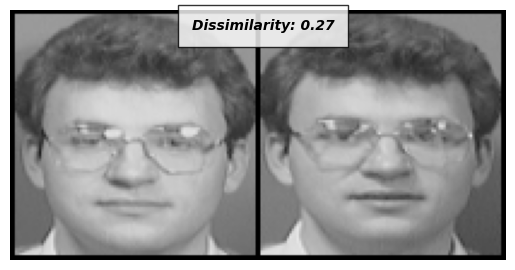

('./data/faces/testing/s5/2.pgm', 0)

Same 1==0

('./data/faces/testing/s7/4.pgm', 2)

Same 1==2

('./data/faces/testing/s5/7.pgm', 0)

Same 1==0

('./data/faces/testing/s6/2.pgm', 1)

Same 1==1

Found Same



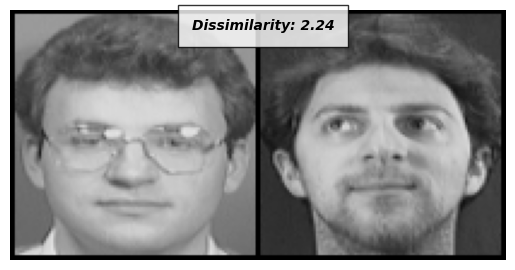

('./data/faces/testing/s5/1.pgm', 0)

Same 0==0

Found Same



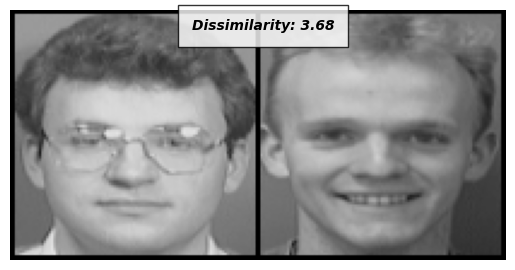

('./data/faces/testing/s6/3.pgm', 1)

Same 2==1

('./data/faces/testing/s5/2.pgm', 0)

Same 2==0

('./data/faces/testing/s5/1.pgm', 0)

Same 2==0

('./data/faces/testing/s6/10.pgm', 1)

Same 2==1

('./data/faces/testing/s6/2.pgm', 1)

Same 2==1

('./data/faces/testing/s7/6.pgm', 2)

Same 2==2

Found Same



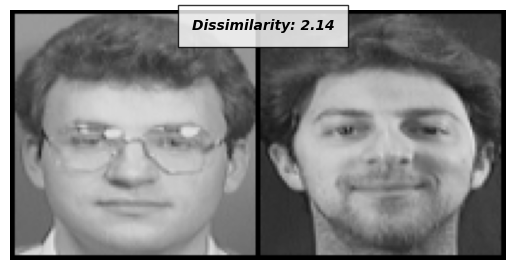

Diff 1==1

Diff 1==2

Found Diff



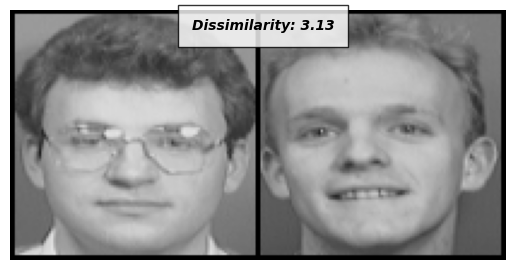

('./data/faces/testing/s7/1.pgm', 2)

Same 1==2

('./data/faces/testing/s6/1.pgm', 1)


Same 1==1
Found Same



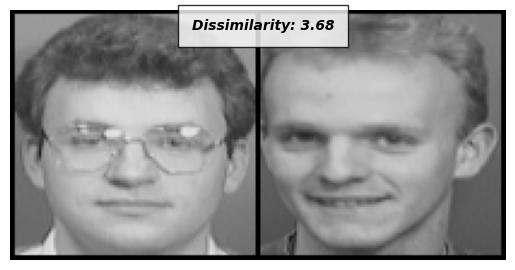

('./data/faces/testing/s6/3.pgm', 1)

Same 0==1

('./data/faces/testing/s5/8.pgm', 0)

Same 0==0

Found Same



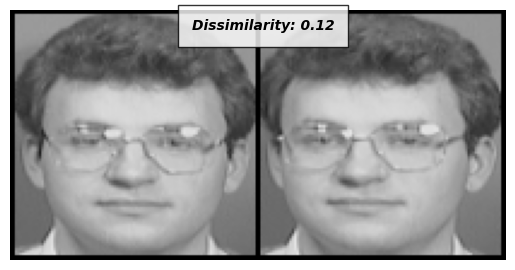

('./data/faces/testing/s7/3.pgm', 2)

Same 1==2

('./data/faces/testing/s7/5.pgm', 2)

Same 1==2

('./data/faces/testing/s7/2.pgm', 2)

Same 1==2

('./data/faces/testing/s5/4.pgm', 0)

Same 1==0

('./data/faces/testing/s5/2.pgm', 0)

Same 1==0

('./data/faces/testing/s6/5.pgm', 1)

Same 1==1

Found Same



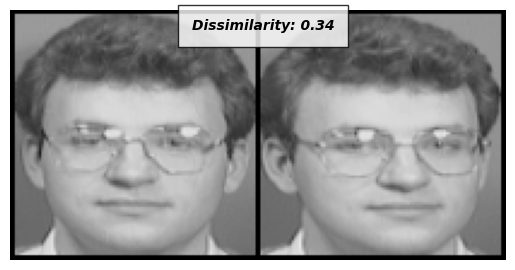

Diff 2==0

Found Diff



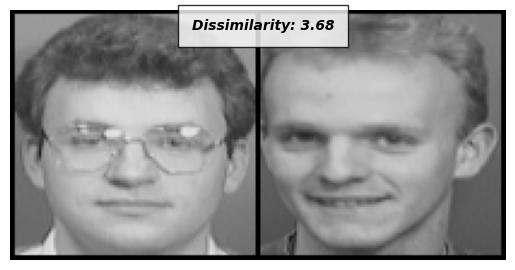

('./data/faces/testing/s5/4.pgm', 0)

Same 2==0

('./data/faces/testing/s5/6.pgm', 0)

Same 2==0

('./data/faces/testing/s6/7.pgm', 1)

Same 2==1

('./data/faces/testing/s7/1.pgm', 2)

Same 2==2

Found Same



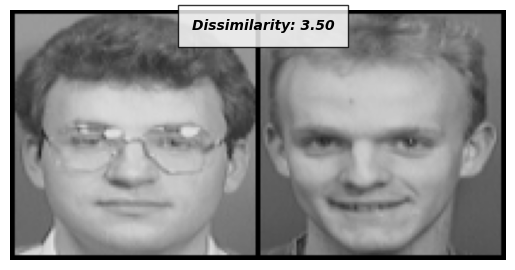

In [36]:
folder_dataset_test = dset.ImageFolder(root = Config.testing_dir) #testing_dir
siamese_dataset = SiameseNetworkDataset(imageFolderDataset = folder_dataset_test,
                                        transform = transforms.Compose([transforms.Resize((100,100)), transforms.ToTensor()]))

##siamese_dataset = nc.SafeDataset(siamese_dataset)

test_dataloader = DataLoader(siamese_dataset,num_workers=6,batch_size=1,shuffle=True)
dataiter = iter(test_dataloader)
x0,_,_ = next(dataiter)

# Check the similarity for the first few images from the test data loader
for i in range(10):
    _,x1,label2 = next(dataiter)
    concatenated = torch.cat((x0,x1),0)

    output1,output2 = myModel(Variable(x0).cuda(),Variable(x1).cuda()) #using the loaded 'myModel'; even 'net' can be used
    #..but using 'myModel' helps a quick test on if the save and load model is working fine. You will replicate the same
    #..in the server.

    euclidean_distance = F.pairwise_distance(output1, output2)
    imshow(torchvision.utils.make_grid(concatenated),'Dissimilarity: {:.2f}'.format(euclidean_distance.item()))

##**Stage 2: Deploy your Face Similarity application on HuggingFace Spaces (10 Marks)**


---




1. [Sign up](https://huggingface.co/join) for a Hugging Face account

2. Once you have an account, create an access token for your account and save it:
    
    - Go to your `Settings`, then click on the `Access Tokens` tab. Click on the `New token` button to create a new User Access Token.
    - Select a role(`write`) and a name for your token
    - Click Generate a token

    To know more about Access Tokens, refer [here](https://huggingface.co/docs/hub/security-tokens).

3. Start a new Hugging Face Space by going to your profile and [clicking "New Space"](https://huggingface.co/new-space)

4. Provide details for your space:
    - Space name
    - License (eg. [MIT](https://opensource.org/licenses/MIT))
    - For Space SDK (software development kit), select `Docker` (**It is mandatory to select *Docker* for this application to work.**)
    - Choose a Docker template: `Blank`
    - Space hardware (CPU basic)
    - Choose whether your Space is public or private
    - Click "Create Space"
    - After Space creation, the files of your repo can be seen via `Files` tab

5. Clone your space repository on to your system
    - Go to 3-dots icon beside Settings, then select `Clone Repository` option
        - `git lfs install`
        - `git clone <your-repo>`
    - Run clone commands in your terminal (Provide your HuggingFace username and access token if prompted for authentication.)

6. Download the project folder **`recognition_api`**, shared along with this notebook, on to your system

7. Add below files from **`recognition_api`** folder to your cloned repository folder
    - `app`, `requirements.txt`, `Dockerfile`, and `.gitattributes`
    - You may need to replace the `.gitattributes` file if it is already present in repository
    - **NOTE:** Do NOT commit and push changes yet.

8. Update files present in your cloned repository
    - Download the Siamese model(trained in colab for face similarity) and place it within **`app/Hackathon_setup/`** folder
    - Update the Siamese model architecture in the **`app/Hackathon_setup/face_recognition_model.py`** file and provide the code in the **`get_similarity()`** function of the **`app/Hackathon_setup/face_recognition.py`** file. (See Deployment related files)
    - Update the **`README.md`** file and include `app_port: 8001`

9. Commit your changes and push to HuggingFace Space repository

10. Access the `App` tab of your repository to see the build progress (debug if error persists) [This step might take sometime.]

11. Once the app has built successfully, you should see below message

    `Application startup complete. Uvicorn running on http://0.0.0.0:8001`

12. Test the Siamese model using the application running on your Space

    Go to 3-dots icon beside Settings, then select `Embed this Space` option, and go to `Direct URL`
    - Select the task, `Face Similarity` for now
    - Select 'Send Anyway' when prompted
    - Upload images and test
    - **NOTE:** When using the Direct URL link via mobile, the camera option will also enable to capture images (Set 1:1 aspect ratio in camera settings before-hand)


##**Stage 3: Build Face Recognition Classification Model with Siamese Representation of Team Data and Deploy on HuggingFace Spaces (10 Marks)**


---


- Build a Face Recognition Classification Model on Team data
    - Collect Team data by running the code cells provided below
        - The collected data images will be stored in the `captured_face_images` directory

        - NOTE: *Since team members will be using separate colab notebooks, they can capture their own face images and then download it and share with other members for model training.* Code cell is provided below to download the data.

    - Train a classifier (use any classifier) with the features extracted from the above trained Siamese network, for your Team Data
    - Save the Classification Model with joblib (if Sklearn classification model is used)

- Deploy on your HuggingFace Space

    - Download the trained models (Siamese model, Classification model) and upload them in your HuggingFace Space repository within **`app/Hackathon_setup/`** folder
    
    - Update the Siamese model architecture in the **`app/Hackathon_setup/face_recognition_model.py`** file (If Required)
    
    - Update the code in the **`get_face_class()`** function of the **`app/Hackathon_setup/face_recognition.py`** file. (See Deployment related files)

- Access the `App` tab of your repository to see the build progress (debug if error persists) [This step might take sometime.]

- Once the app has built successfully, you should see below message

    `Application startup complete. Uvicorn running on http://0.0.0.0:8001`

- Test the model's Face Recognition functionality using the application running on your Space

    Go to 3-dots icon beside Settings, then select `Embed this Space` option, and go to `Direct URL`
    - Select the task, `Face Recognition`
    - Select 'Send Anyway' when prompted
    - Upload your image and test
    - **NOTE:** When using the Direct URL link via mobile, the camera option will also enable to capture images (Set 1:1 aspect ratio in camera settings before-hand)


In [ ]:
# @title Run this cell to Setup Image Capturing in Colab {display-mode: "form"}

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import imageio
import datetime
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

AREA_THRESHOLD = 2304

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)

  im = Image.open(filename)
  im1 = im.crop((80, 0, 560, 480))
  im1.save(filename)

  return filename


def save_faces(miniframe, filepath):
    TRAINSET = "lbpcascade_frontalface.xml"
    classifier = cv2.CascadeClassifier(TRAINSET)
    faces = classifier.detectMultiScale(miniframe)
    image = get_large_face(miniframe, faces)
    if not isinstance(image, np.ndarray):
        return {"status" : False}
    plt.imshow(image)
    plt.show()
    #cv2.imwrite(filepath, image)
    imageio.imwrite(filepath, image)
    return {"status" : True}

def get_large_face(miniframe, faces):
    images = []
    face_areas = []
    required_image = 0
    for x,y,w,h in faces:
        face_cropped = miniframe[y:y+h, x:x+w]
        face_areas.append(w*h)
        images.append(face_cropped)
        required_image = images[np.argmax(face_areas)]
    if not face_areas:
        return 0
    if face_areas[np.argmax(face_areas)] < AREA_THRESHOLD:
        return 0

    return required_image

def save_image(filename, class_name):
    base_path = "captured_face_images/"

    pathlib.Path(base_path + class_name).mkdir(parents=True, exist_ok=True)
    file_name = class_name + "_" + datetime.datetime.now().strftime("%s") + ".jpg"
    filepath = base_path +class_name + "/" + file_name

    image = Image.open(filename)
    miniframe = np.asarray(image)
    status = save_faces(miniframe, filepath)
    if status['status']:
        print("Image saved in " + filepath, flush = True)
    else:
        print("Face not found!\nRetry!")


In [ ]:
# @title Capture an Image for Person1 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person1"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

<IPython.core.display.Javascript object>

NotAllowedError: Permission denied


NameError: name 'filename' is not defined

In [ ]:
# @title Capture an Image for Person2 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person2"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Capture an Image for Person3 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person3"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Capture an Image for Person4 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person4"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Capture an Image for Person5 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person5"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Capture an Image for Person6 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person6"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Capture an Image for Person7 $ $  [Re-run this cell to capture another image] {display-mode: "form"}

class_name = "Person7"

from IPython.display import Image as IPyImage
try:
  filename = take_photo()
  #print('Saved to {}'.format(filename))
  # Show the image which was just taken.
  #display(IPyImage(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

save_image(filename, class_name)

In [ ]:
# @title Download Collected Images $ $ [OPTIONAL]  {display-mode: "form"}

from google.colab import files
!zip -r "captured_face_images.zip" "captured_face_images"
files.download('captured_face_images.zip')
print("Downloaded captured_face_images.zip !!")

In [ ]:
!cd captured_face_images && ls -a

**While uploading the team images manually to captured_face_images. this file .ipynb_checkpoints will be created and make issue to delet run the below code**

In [ ]:
rm -rf `find -type d -name .ipynb_checkpoints`

In [ ]:
# Here simple ImageFolder is enough; we don't need SiameseDataSet
finalClassifierDset = dset.ImageFolder(root='./captured_face_images',
                                       transform = transforms.Compose([transforms.Grayscale(num_output_channels = 1), transforms.Resize((100,100)), transforms.ToTensor()]))

In [ ]:
# Dataloader using the dataset created above.
representation_dataloader = DataLoader(finalClassifierDset, shuffle=False, num_workers=8, batch_size=100)

In [106]:
# Load the state dict of the siamese model
# <YOUR CODE HERE>
# Ensure the model is in evaluation mode
myModel.eval()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)

siamese_features = []
labels = []

classification_dataset = dset.ImageFolder(root=r'./data/faces',
                                       transform = transforms.Compose([transforms.Grayscale(num_output_channels = 1), transforms.Resize((100,100)), transforms.ToTensor()]))

classification_dataloader = DataLoader(classification_dataset, shuffle=False, num_workers=8, batch_size=100)
# Iterate through the representation_dataloader to extract features
with torch.no_grad(): # Disable gradient calculation for inference
    for img_tensor, label_idx in classification_dataloader:
        # Move image to the same device as the model
        img_tensor = img_tensor.to(device)

        # Extract features using the Siamese network's forward_once method
        # The output of forward_once is a 5-dimensional embedding for each image
        feature_vector = myModel.forward_once(img_tensor)

        # Append the feature vector (as a numpy array) and the class label
        # .squeeze(0) removes the batch dimension of 1 if present
        siamese_features.extend(feature_vector.cpu().numpy().reshape(feature_vector.size(0), -1)) # Reshape to (batch_size, num_features)
        # Iterate through the batch of labels and append each one
        for i in range(label_idx.size(0)):
            labels.append(classification_dataset.classes[label_idx[i].item()]) # Get actual class name from dataset classes

# Convert lists to numpy arrays for use with scikit-learn
X_siamese = np.array(siamese_features)
y_siamese = np.array(labels)

print(f"Shape of extracted Siamese features (X_siamese): {X_siamese.shape}")
print(f"Shape of corresponding labels (y_siamese): {y_siamese.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Shape of extracted Siamese features (X_siamese): (400, 5)
Shape of corresponding labels (y_siamese): (400,)


In [ ]:
# Get a siamese representation of each of your data points i.e. for each of your team images.
## For example (if your image is of the size 100*100 above)
# <YOUR CODE HERE>


**Train a Classifier for Face Recognition**

You can use any classifier with the features extracted from the above trained Siamese network of your team data. If required, you have to convert torch variable to numpy array before using SkLearn.

In [83]:
# Below is the class of custom dataset which arranges images in pairs and gives the labels. if both are same, then label will be 0 otherwise 1
# As our images are in .pgm extension (portable gray map) we converting them 'L' to store luminance which is basically single channel image.

class SiameseNetworkDatasetForClassiciation(Dataset):
    def __init__(self,imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset
        self.transform = transform

    # Overriding the data retriever (__getitem__) to provide a pair of images + similar/dissimilar label
    def __getitem__(self,index):
        label = None
        img0_tuple = random.choice(self.imageFolderDataset.imgs)
        #we need to make sure approx 50% of images are in the same class
        should_get_same_class = True
        if should_get_same_class:
            while True:
                #keep looping till the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs)
                print(f"{img1_tuple}\n")
                print(f"Same {img0_tuple[1]}=={img1_tuple[1]}\n")
                if img0_tuple[1]==img1_tuple[1]:
                    print(type(img1_tuple[0]))
                    print(img1_tuple[0])
                    label = img1_tuple[0].split('/')[-2].replace('s','')
                    print(f"Found Same at folder {label}\n")
                    break
        else:
            while True:
                #keep looping till a different class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs)
                print(f"Diff {img0_tuple[1]}=={img1_tuple[1]}\n")
                if img0_tuple[1] !=img1_tuple[1]:
                    label = img1_tuple[0].split('/')[-1]
                    print("Found Same at folder {label}\n")
                    print("Found Diff\n")
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])
        img0 = img0.convert("L")
        img1 = img1.convert("L")

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)

        # Add to the return value the folder numbr which becomes the label
        print("------Returning\n")
        return img0, label, torch.from_numpy(np.array([int(img1_tuple[1]!=img0_tuple[1])],dtype=np.float32))

    def __len__(self):
        return len(self.imageFolderDataset.imgs)

In [84]:
classification_folder_dataset_test = dset.ImageFolder(root = r'data/faces') #testing_dir
classification_dataset = SiameseNetworkDatasetForClassiciation(imageFolderDataset = classification_folder_dataset_test,
                                        transform = transforms.Compose([transforms.Resize((100,100)), transforms.ToTensor()]))

In [85]:
next(iter(classification_dataset))

('data/faces/training/s40/9.pgm', 1)

Same 1==1

<class 'str'>
data/faces/training/s40/9.pgm
Found Same at folder 40

------Returning



(tensor([[[0.4627, 0.4706, 0.4627,  ..., 0.4784, 0.4745, 0.4667],
          [0.4745, 0.4706, 0.4745,  ..., 0.4745, 0.4745, 0.4784],
          [0.4706, 0.4667, 0.4706,  ..., 0.4784, 0.4745, 0.4706],
          ...,
          [0.2471, 0.2667, 0.2627,  ..., 0.3804, 0.3882, 0.3882],
          [0.2588, 0.2549, 0.2627,  ..., 0.3843, 0.3843, 0.3922],
          [0.2588, 0.2627, 0.2588,  ..., 0.4824, 0.4314, 0.4000]]]),
 '40',
 tensor([0.]))

In [77]:
type(classification_folder_dataset_test)

torchvision.datasets.folder.ImageFolder

In [86]:
len(classification_dataset)

400

In [92]:
#Now create X and y

X = []
y = []
for i in range(len(classification_dataset)):
  X.append(classification_dataset[i][0].numpy().flatten())
  y.append(classification_dataset[i][1])

Streaming output truncated to the last 5000 lines.
<class 'str'>
data/faces/training/s21/6.pgm
Found Same at folder 21

------Returning

('data/faces/training/s36/7.pgm', 1)

Same 1==1

<class 'str'>
data/faces/training/s36/7.pgm
Found Same at folder 36

------Returning

('data/faces/training/s24/8.pgm', 1)

Same 1==1

<class 'str'>
data/faces/training/s24/8.pgm
Found Same at folder 24

------Returning

('data/faces/training/s3/7.pgm', 1)

Same 1==1

<class 'str'>
data/faces/training/s3/7.pgm
Found Same at folder 3

------Returning

('data/faces/training/s11/4.pgm', 1)

Same 0==1

('data/faces/training/s18/10.pgm', 1)

Same 0==1

('data/faces/training/s20/2.pgm', 1)

Same 0==1

('data/faces/training/s38/5.pgm', 1)

Same 0==1

('data/faces/training/s11/3.pgm', 1)

Same 0==1

('data/faces/training/s38/4.pgm', 1)

Same 0==1

('data/faces/training/s33/5.pgm', 1)

Same 0==1

('data/faces/training/s30/10.pgm', 1)

Same 0==1

('data/faces/training/s30/8.pgm', 1)

Same 0==1

('data/faces/train

In [93]:
len(X), len (y)

(400, 400)

In [94]:
print(y[0], '\n', X[0])

36 
 [0.45882353 0.4509804  0.4509804  ... 0.21568628 0.1882353  0.25490198]


In [117]:
# YOUR CODE HERE for training a classifier. You can use simple MLP or Sklearn models.
# Note: Ensure you convert torch variable to numpy array before using SkLearn.
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


#X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(siamese_features, labels, stratify=labels, random_state=42)



0.95

In [124]:
classifier = MLPClassifier(random_state=42, max_iter=200).fit(X_train, y_train)
classifier.score(X_test, y_test)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.92

In [122]:
clf = DecisionTreeClassifier(random_state=32).fit(X_train, y_train)
clf.score(X_test, y_test)

0.95

In [127]:
from sklearn.svm import SVC

svm_classifier = SVC(random_state=42, verbose=True)
svm_classifier.fit(X_train, y_train)
print(f"SVM Classifier Accuracy: {svm_classifier.score(X_test, y_test)}")

[LibSVM]SVM Classifier Accuracy: 0.92


**Save your classification model**

* Save your sklearn models using joblib



In [129]:
# YOUR CODE HERE for saving the model.
# Note: For SkLearn classifier use joblib for saving the model.
import joblib
joblib.dump(classifier, 'classifier.joblib')

['classifier.joblib']

In [ ]:
import joblib

# Load the saved classifier
loaded_classifier = joblib.load('classifier.joblib')

# Use the loaded classifier to make predictions on the test set
predictions = loaded_classifier.predict(X_test)

# You can also evaluate its accuracy (if it's a classification model)
accuracy = loaded_classifier.score(X_test, y_test)
print(f"Accuracy of loaded classifier: {accuracy:.2f}")

**Download your trained model using the code below**
* Given the path of model file the following code downloads it through the browser

In [ ]:
from google.colab import files
files.download('decision_tree_model.sav')
#files.download('<model_file_path>')